# Walmart EDA Case Study

This notebook presents a comprehensive EDA and statistical analysis of the Walmart dataset as outlined in the case study instructions.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("/content/walmart_data.txt")

# Preview data
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


## 1. Dataset Overview and Basic Info

In [8]:
# Data types
df.dtypes

# Dataset shape
print("Shape of dataset:", df.shape)

# Missing values
df.isnull().sum()

Shape of dataset: (550068, 10)


,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


## 2. Detect Null Values and Outliers

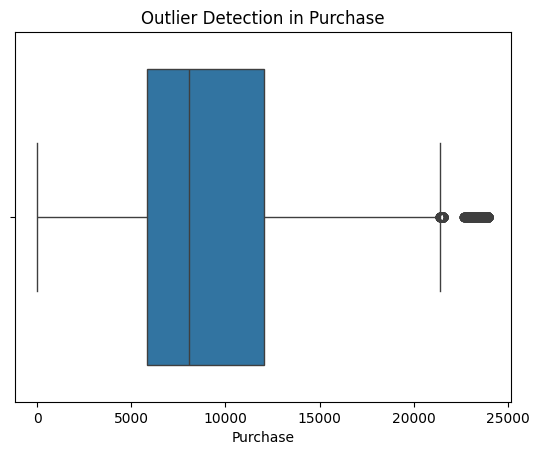

In [9]:
# Boxplot for Purchase
sns.boxplot(x=df['Purchase'])
plt.title('Outlier Detection in Purchase')
plt.show()

# Clipping Purchase values
lower = df['Purchase'].quantile(0.05)
upper = df['Purchase'].quantile(0.95)
df['Purchase_clipped'] = np.clip(df['Purchase'], lower, upper)


## 3. Data Exploration

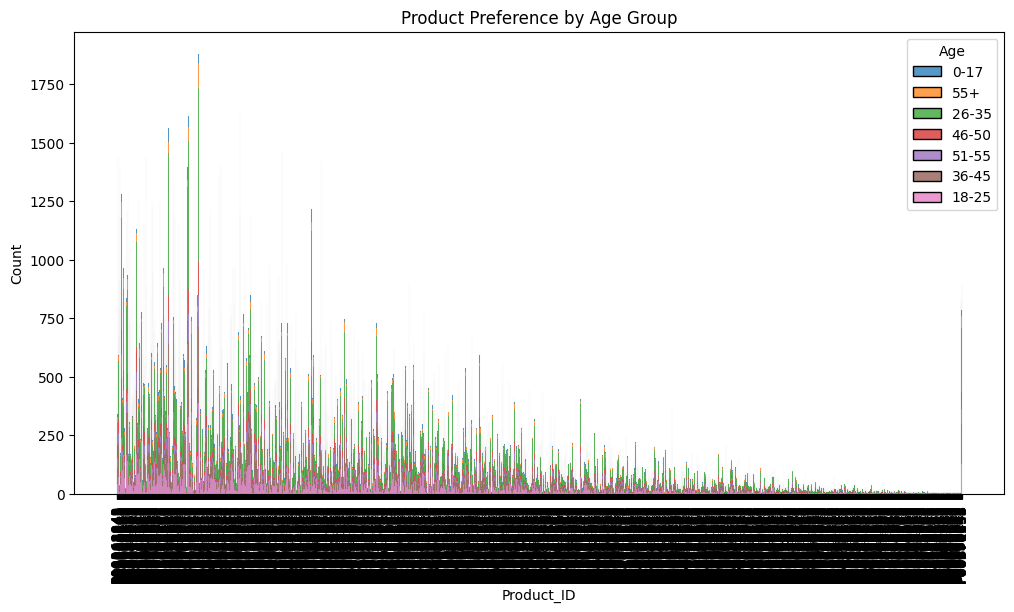

In [10]:
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='Product_ID', hue='Age', multiple='stack', bins=30)
plt.xticks(rotation=90)
plt.title('Product Preference by Age Group')
plt.show()

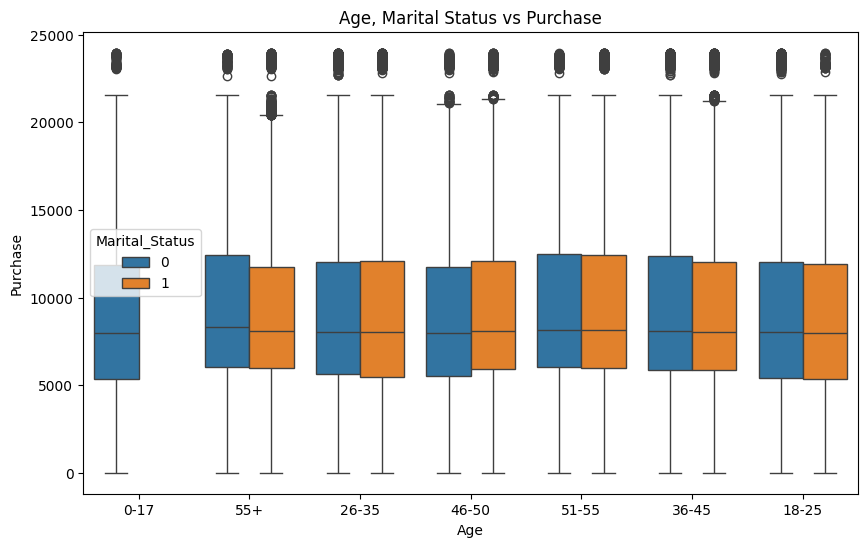

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Age', y='Purchase', hue='Marital_Status', data=df)
plt.title('Age, Marital Status vs Purchase')
plt.show()

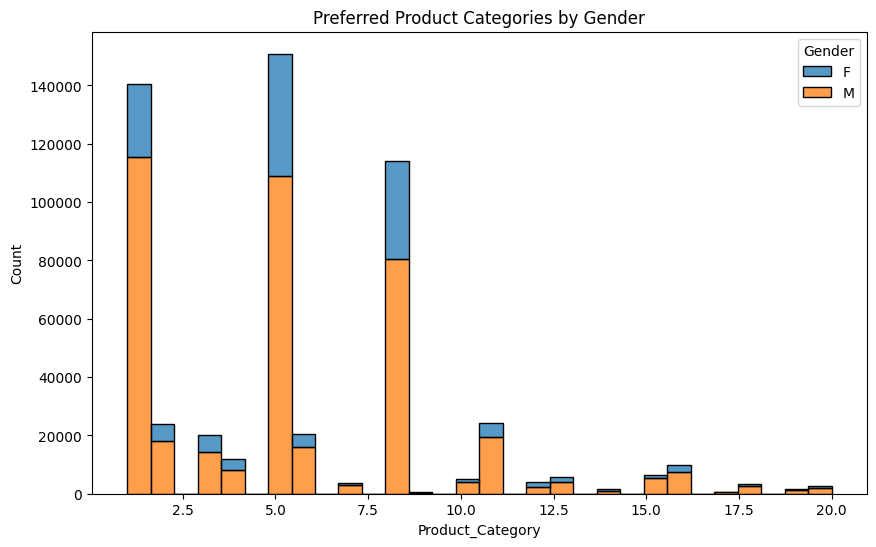

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Product_Category', hue='Gender', multiple='stack', bins=30)
plt.title('Preferred Product Categories by Gender')
plt.show()

## 4. Gender Impact on Purchase Amount using CLT and Bootstrapping

In [13]:
def bootstrap_mean_ci(data, num_samples=1000, sample_size=None, ci=95):
    means = []
    for _ in range(num_samples):
        sample = data.sample(n=sample_size if sample_size else len(data), replace=True)
        means.append(sample.mean())
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return (lower, upper), means

for gender in df['Gender'].unique():
    print(f"Gender: {gender}")
    purchase_data = df[df['Gender'] == gender]['Purchase']
    for size in [None, 300, 3000, 30000]:
        ci, _ = bootstrap_mean_ci(purchase_data, sample_size=size)
        print(f"Sample size: {size if size else 'Full'} -> CI: {ci}")
    print("----")


Gender: F
Sample size: Full -> CI: (np.float64(8706.362692089626), np.float64(8758.443095082064))
Sample size: 300 -> CI: (np.float64(8186.2373333333335), np.float64(9314.398666666666))
Sample size: 3000 -> CI: (np.float64(8563.620908333332), np.float64(8894.278558333333))
Sample size: 30000 -> CI: (np.float64(8680.18655), np.float64(8789.822758333332))
----
Gender: M
Sample size: Full -> CI: (np.float64(9422.925486108932), np.float64(9452.820551152781))
Sample size: 300 -> CI: (np.float64(8852.6405), np.float64(9980.724416666666))
Sample size: 3000 -> CI: (np.float64(9248.46075), np.float64(9615.582266666666))
Sample size: 30000 -> CI: (np.float64(9377.028806666667), np.float64(9493.464331666666))
----


## 5. Marital Status Impact on Purchase Amount

In [14]:
for status in df['Marital_Status'].unique():
    print(f"Marital Status: {status}")
    purchase_data = df[df['Marital_Status'] == status]['Purchase']
    for size in [None, 300, 3000, 30000]:
        ci, _ = bootstrap_mean_ci(purchase_data, sample_size=size)
        print(f"Sample size: {size if size else 'Full'} -> CI: {ci}")
    print("----")


Marital Status: 0
Sample size: Full -> CI: (np.float64(9249.122526337183), np.float64(9282.842145421902))
Sample size: 300 -> CI: (np.float64(8687.707583333333), np.float64(9845.574333333334))
Sample size: 3000 -> CI: (np.float64(9091.718066666666), np.float64(9447.1196))
Sample size: 30000 -> CI: (np.float64(9208.698000833334), np.float64(9319.876453333334))
----
Marital Status: 1
Sample size: Full -> CI: (np.float64(9241.008573824982), np.float64(9281.402136799548))
Sample size: 300 -> CI: (np.float64(8733.836000000001), np.float64(9828.631))
Sample size: 3000 -> CI: (np.float64(9100.774183333333), np.float64(9436.664716666666))
Sample size: 30000 -> CI: (np.float64(9207.200309166667), np.float64(9313.645701666666))
----


## 6. Age Group Impact on Purchase Amount

In [15]:
for age in df['Age'].unique():
    print(f"Age Group: {age}")
    purchase_data = df[df['Age'] == age]['Purchase']
    for size in [None, 300, 3000, 30000]:
        ci, _ = bootstrap_mean_ci(purchase_data, sample_size=size)
        print(f"Sample size: {size if size else 'Full'} -> CI: {ci}")
    print("----")


Age Group: 0-17
Sample size: Full -> CI: (np.float64(8852.667615216527), np.float64(9008.99861607734))
Sample size: 300 -> CI: (np.float64(8359.955750000001), np.float64(9535.948083333335))
Sample size: 3000 -> CI: (np.float64(8749.187533333332), np.float64(9114.403325))
Sample size: 30000 -> CI: (np.float64(8878.332935), np.float64(8988.550201666667))
----
Age Group: 55+
Sample size: Full -> CI: (np.float64(9271.582905505953), np.float64(9402.407219587054))
Sample size: 300 -> CI: (np.float64(8739.320166666666), np.float64(9949.602583333333))
Sample size: 3000 -> CI: (np.float64(9168.463958333334), np.float64(9519.712116666666))
Sample size: 30000 -> CI: (np.float64(9284.724249166668), np.float64(9391.999025833335))
----
Age Group: 26-35
Sample size: Full -> CI: (np.float64(9232.07759373278), np.float64(9272.414203368142))
Sample size: 300 -> CI: (np.float64(8676.615249999999), np.float64(9834.121500000001))
Sample size: 3000 -> CI: (np.float64(9084.500166666667), np.float64(9430.3979

## 7. Final Reports

- Check if confidence intervals for gender overlap
- Check if confidence intervals for marital status overlap
- Check if confidence intervals for age groups overlap



In [16]:
def bootstrap_mean_ci(data, num_samples=1000, sample_size=None, ci=95):
    means = []
    for _ in range(num_samples):
        sample = data.sample(n=sample_size if sample_size else len(data), replace=True)
        means.append(sample.mean())
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return (lower, upper), means

In [17]:
male_data = df[df['Gender'] == 'M']['Purchase']
female_data = df[df['Gender'] == 'F']['Purchase']

male_ci, _ = bootstrap_mean_ci(male_data)
female_ci, _ = bootstrap_mean_ci(female_data)

print(f"Male CI: {male_ci}")
print(f"Female CI: {female_ci}")

overlap = not (male_ci[1] < female_ci[0] or female_ci[1] < male_ci[0])
print("Do they overlap?", overlap)

Male CI: (np.float64(9421.563756611202), np.float64(9452.920027506945))
Female CI: (np.float64(8710.704027715396), np.float64(8759.995401262066))
Do they overlap? False


In [18]:
married_data = df[df['Marital_Status'] == 1]['Purchase']
unmarried_data = df[df['Marital_Status'] == 0]['Purchase']

married_ci, _ = bootstrap_mean_ci(married_data)
unmarried_ci, _ = bootstrap_mean_ci(unmarried_data)

print(f"Married CI: {married_ci}")
print(f"Unmarried CI: {unmarried_ci}")

overlap = not (married_ci[1] < unmarried_ci[0] or unmarried_ci[1] < married_ci[0])
print("Do they overlap?", overlap)

Married CI: (np.float64(9241.721512334858), np.float64(9281.930249914572))
Unmarried CI: (np.float64(9248.509531581525), np.float64(9284.146588099073))
Do they overlap? True


In [19]:
age_groups = df['Age'].unique()
age_cis = {}

for age in age_groups:
    data = df[df['Age'] == age]['Purchase']
    ci, _ = bootstrap_mean_ci(data)
    age_cis[age] = ci
    print(f"{age}: {ci}")

0-17: (np.float64(8847.014915243015), np.float64(9014.561672295062))
55+: (np.float64(9269.261359514509), np.float64(9399.120446196057))
26-35: (np.float64(9232.627987881797), np.float64(9272.567324682244))
46-50: (np.float64(9160.351047023041), np.float64(9254.077772915254))
51-55: (np.float64(9483.463385366615), np.float64(9586.012538635361))
36-45: (np.float64(9302.912392853572), np.float64(9362.151998400188))
18-25: (np.float64(9137.69648354405), np.float64(9199.215290236805))


## 8. Recommendations
Gender Promotions: If average spending does not differ significantly by gender, Walmart should keep gender-neutral campaigns or validate differences via A/B testing.

Marital Status Segmentation: Differentiate offers for married customers (family-focused) and singles (individual products or experiences).

Age Group Targeting: Allocate marketing budget to target higher spending age segments.

Statistical Monitoring: Recalculate confidence intervals quarterly to ensure customer behavior hasn’t shifted.

Optimize Personalization: Use the insights from CI analysis to build more personalized shopping experiences in-store and online.



Comment

comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment

Comment